# Backtesting ML Regression-Based

In [ ]:
???

Classification Strategy | Regression Strategy
-|-
![](src/res_classification.png) | ![](src/res_regression.png)

## Load the model

In [2]:
import pickle

In [3]:
with open('models/model_dt_regression.pkl', 'rb') as f:
    model_dt = pickle.load(f)

In [4]:
model_dt

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.8172675396062935, 0.9705882352941176, 'Volume <= 78979100.0\nsquared_error = 3.138\nsamples = 1260\nvalue = 0.112'),
 Text(0.6496162857091067, 0.9117647058823529, 'Volume <= 78451200.0\nsquared_error = 3.099\nsamples = 1248\nvalue = 0.127'),
 Text(0.7334419126577001, 0.9411764705882353, 'True  '),
 Text(0.6472961000942575, 0.8529411764705882, 'Open <= 262.304\nsquared_error = 3.047\nsamples = 1247\nvalue = 0.12'),
 Text(0.4807768996519722, 0.7941176470588235, 'Volume <= 46663750.0\nsquared_error = 3.01\nsamples = 1027\nvalue = 0.175'),
 Text(0.38255872969837584, 0.7352941176470589, 'Volume <= 39176800.0\nsquared_error = 2.429\nsamples = 945\nvalue = 0.218'),
 Text(0.3390915023201856, 0.6764705882352942, 'Open <= 260.32\nsquared_error = 2.113\nsamples = 886\nvalue = 0.162'),
 Text(0.31304379350348027, 0.6176470588235294, 'Open <= 258.312\nsquared_error = 2.108\nsamples = 879\nvalue = 0.152'),
 Text(0.2783497679814385, 0.5588235294117647, 'Volume <= 38601750.0\nsquared_error = 2.

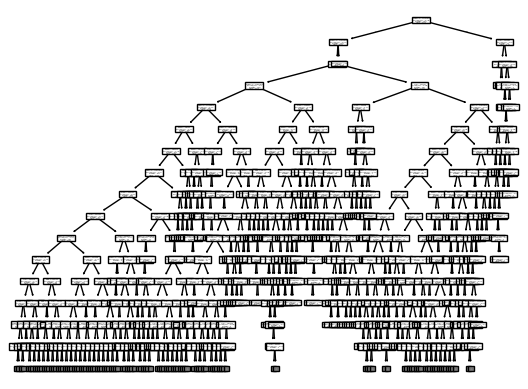

In [13]:
from sklearn.tree import plot_tree

plot_tree(decision_tree=model_dt, feature_names=model_dt.feature_names_in_, max_depth=15)

## Load the data

In [14]:
import pandas as pd

df = pd.read_excel('data/Microsoft_LinkedIn_Processed.xlsx', index_col=0, parse_dates=['Date'])
df

,Open,High,Low,Close,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,56.325228,56.582507,55.902560,56.058762,21220800,1.549143,UP
2016-12-09,56.214968,56.959234,56.169027,56.940857,27349400,0.321692,UP
2016-12-12,56.803028,57.244073,56.711145,57.124622,20198100,1.286112,UP
2016-12-13,57.427836,58.273172,57.188938,57.868881,35718900,-0.478622,DOWN
2016-12-14,57.887258,58.300739,57.455399,57.593227,30352700,-0.159789,DOWN
...,...,...,...,...,...,...,...
2023-03-09,255.820007,259.559998,251.580002,252.320007,26653400,-1.500467,DOWN
2023-03-10,251.080002,252.789993,247.600006,248.589996,28321800,2.099087,UP
2023-03-13,247.399994,257.910004,245.729996,253.919998,33339700,2.634307,UP


## Backtesting.py Library

### Create your Strategy Class

In [6]:
from backtesting import Backtest, Strategy

/home/mlovera/dev/algorithmic-trading/.venv/lib/python3.12/site-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [16]:
class Regression(Strategy):
    def init(self):
        self.model = model_dt
        self.already_bought = False

    def next(self):
        explanatory_today = self.data.df.iloc[[-1],:]
        forecast_tomorrow = model_dt.predict(explanatory_today)[0]
        
        # conditions to buy or sell
        if forecast_tomorrow > 5 and self.already_bought == False:
            self.buy()
            self.already_bought = True

        elif forecast_tomorrow < -5 and self.already_bought == True:
            self.sell()
            self.already_bought = False
        else:
            pass

### Define initial conditions

In [17]:
df_explanatory = df.drop(columns=['change_tomorrow', 'change_tomorrow_direction'])

In [18]:
bt = Backtest(df_explanatory, Regression,
              cash=10000, commission=.002, exclusive_orders=True)

### Run backtesting

In [19]:
results = bt.run()

/tmp/ipykernel_12611/695169841.py:1: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  results = bt.run()


### Interpret backtesting results

In [20]:
results.to_frame(name='Values').loc[:'Return [%]']

,Values
Start,2016-12-08 00:00:00
End,2023-03-15 00:00:00
Duration,2288 days 00:00:00
Exposure Time [%],80.520305
Equity Final [$],17481.086193
Equity Peak [$],24008.875202
Commissions [$],915.421555
Return [%],74.810862


### Visualize the strategy performance

In [21]:
bt.plot(filename='reports_backtesting/backtesting_regression.html', open_browser=True)

GridPlot(id='p1336', ...)